 Data Loading and Standardization 
Total Registered Products (Local + Imported): 8707
Source_Type
Imported Drugs      6186
Local Production    2521
Name: count, dtype: int64
--------------------------------------------------

Overall Market Share (Local vs. Imported) 
Source_Type
Imported Drugs      71.05
Local Production    28.95
Name: proportion, dtype: float64


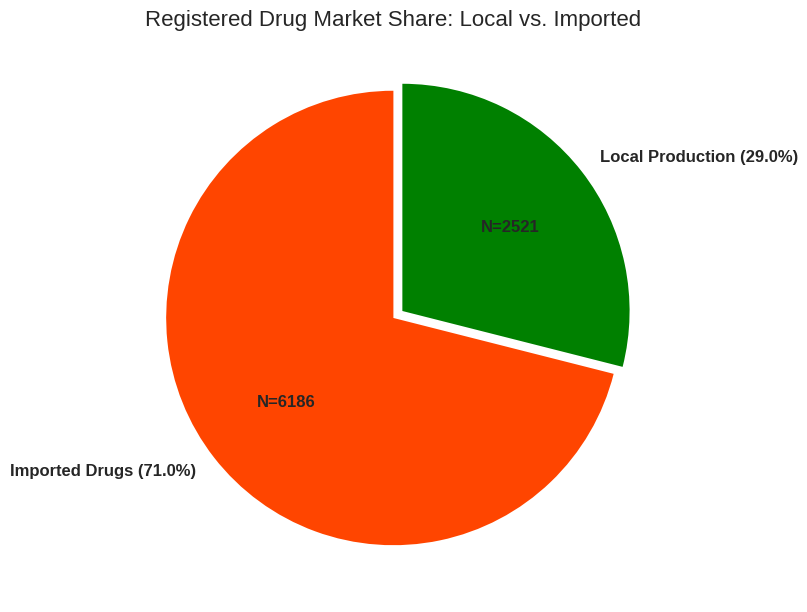

--------------------------------------------------

Top 10 Local Manufacturing Companies
Manufacture Name
Pharmaceutical Solution Industries (PSI)                         427
TABUK PHARMACEUTICAL MANUFACTURING CO.                           377
SPIMACO                                                          336
Jazeera Pharmaceutical Industries (JPI)                          239
Jamjoom Pharmaceuticals Factory Company                          233
RIYADH PHARMA                                                    149
(Avalon Pharma) Middle East Pharmaceutical Industries Co. Ltd     98
SAJA-SAUDI ARABIAN JAPANESE PHARMACEUTICAL CO                     81
DEEF PHARMACEUTICAL INDUSTRIES                                    74
Med city                                                          71
Name: count, dtype: int64


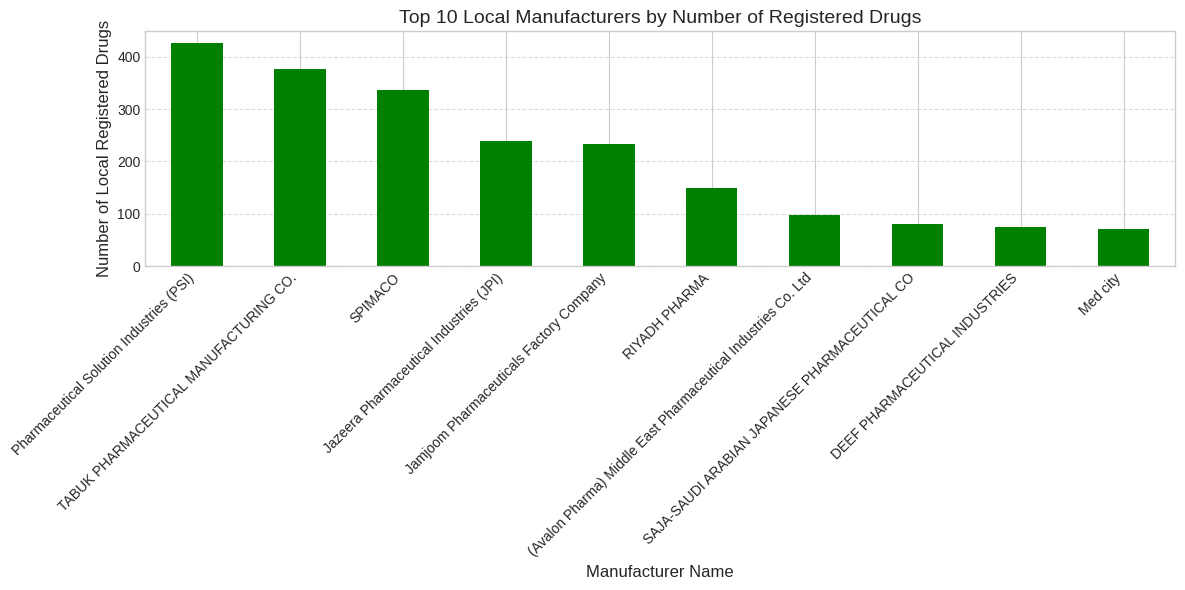

--------------------------------------------------

Top 10 Local Companies: Production Profile by Drug Type ---
DrugType                                            --  Biological  Generic  \
Manufacture Name                                                              
Pharmaceutical Solution Industries (PSI)             0           0      423   
TABUK PHARMACEUTICAL MANUFACTURING CO.               0           0      377   
SPIMACO                                              0           6      315   
Jazeera Pharmaceutical Industries (JPI)              0           0      224   
Jamjoom Pharmaceuticals Factory Company              0           0      233   
RIYADH PHARMA                                        0           0      145   
(Avalon Pharma) Middle East Pharmaceutical Indu...   1           0       96   
SAJA-SAUDI ARABIAN JAPANESE PHARMACEUTICAL CO        0           0       64   
DEEF PHARMACEUTICAL INDUSTRIES                       0           0       72   
Med city           

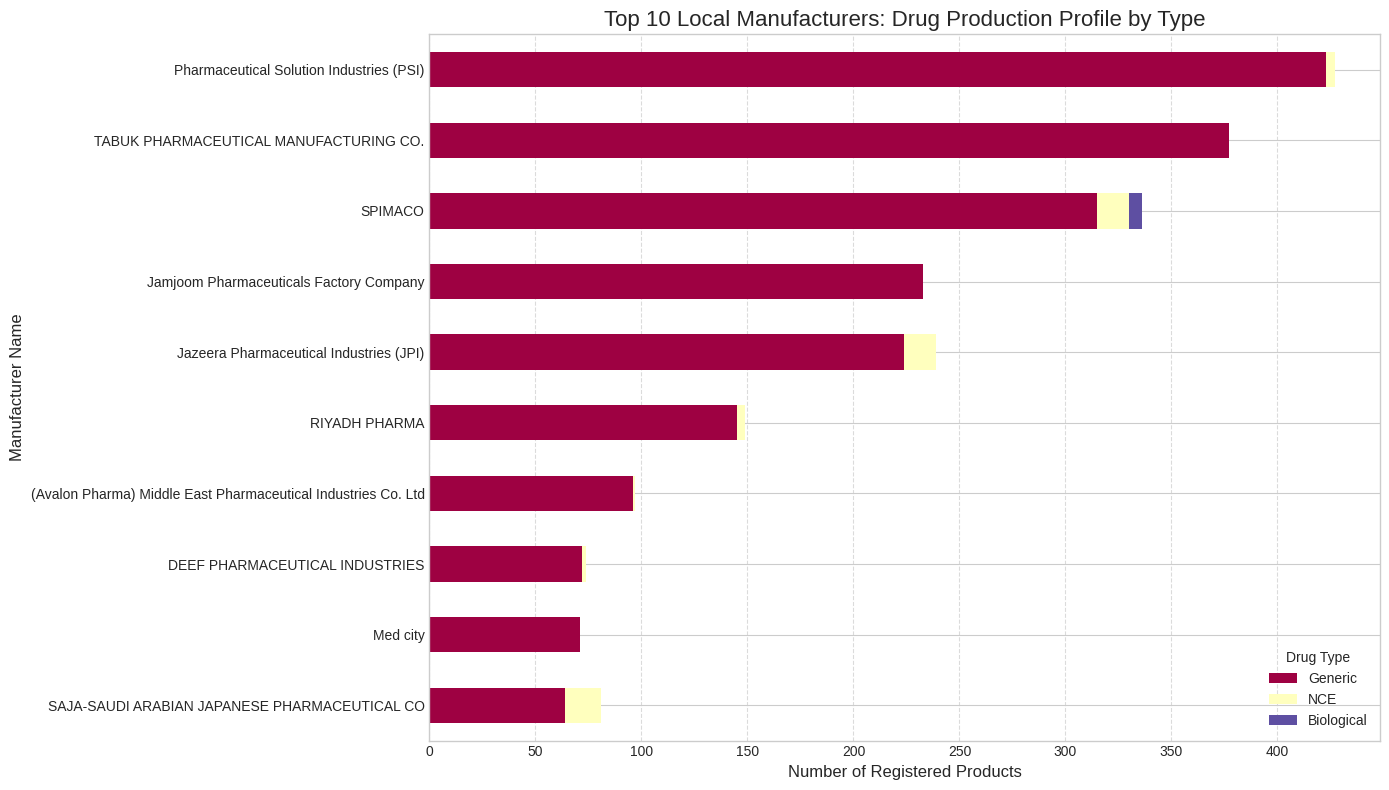

--------------------------------------------------

 Strategic Gap Analysis: Local vs. Imported Drug Types ---
                     Local Production Share (%)  Imported Drugs Share (%)  \
DrugType                                                                    
NCE                                         4.4                      31.7   
Biological                                  0.4                      12.7   
Radiopharmaceutical                         0.0                       0.1   
-                                           0.0                       0.1   
--                                          0.0                       0.0   
Generic                                    95.1                      55.4   

                     Strategic Gap (Import - Local) (%)  
DrugType                                                 
NCE                                                27.3  
Biological                                         12.3  
Radiopharmaceutical                     

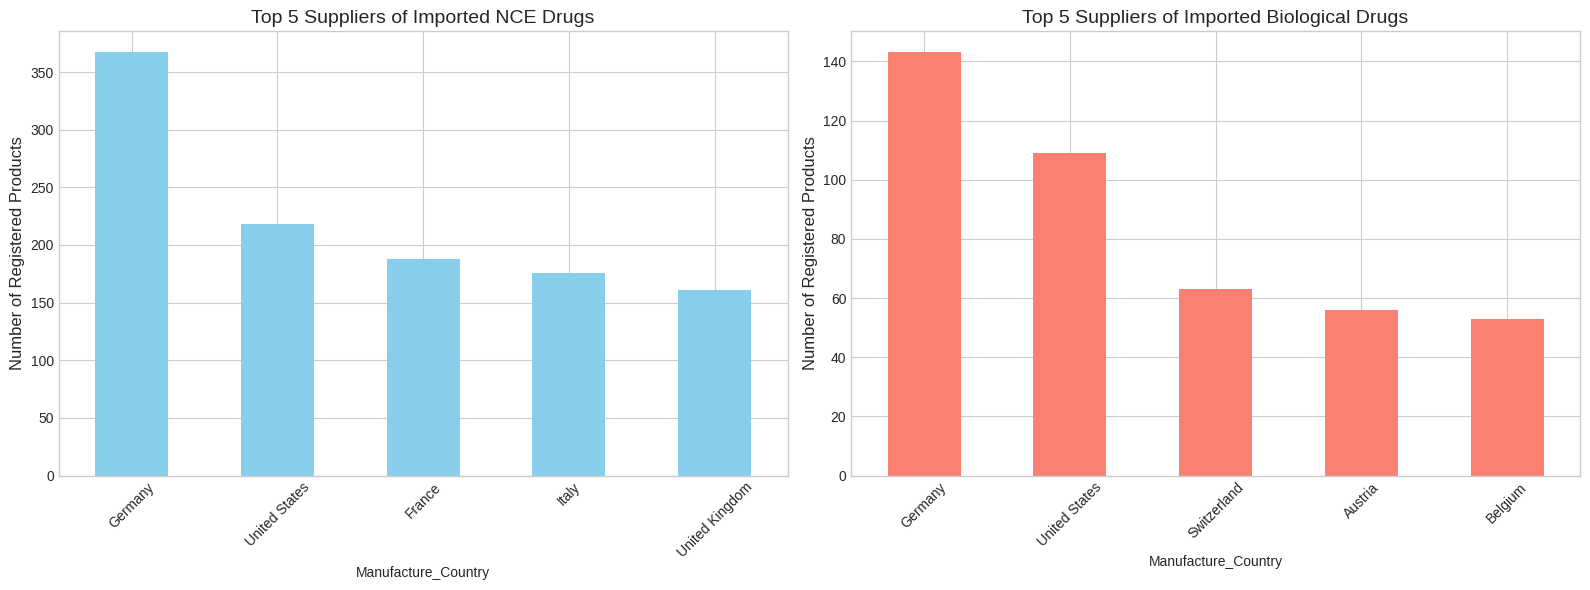

--------------------------------------------------

Top 5 Suppliers of Imported Generic Drugs (Direct Competition) ---
Total Imported Generic Products: 3425
Manufacture_Country
India                   673
Jordan                  644
United Arab Emirates    286
Egypt                   166
Germany                 130
Name: count, dtype: int64
--------------------------------------------------


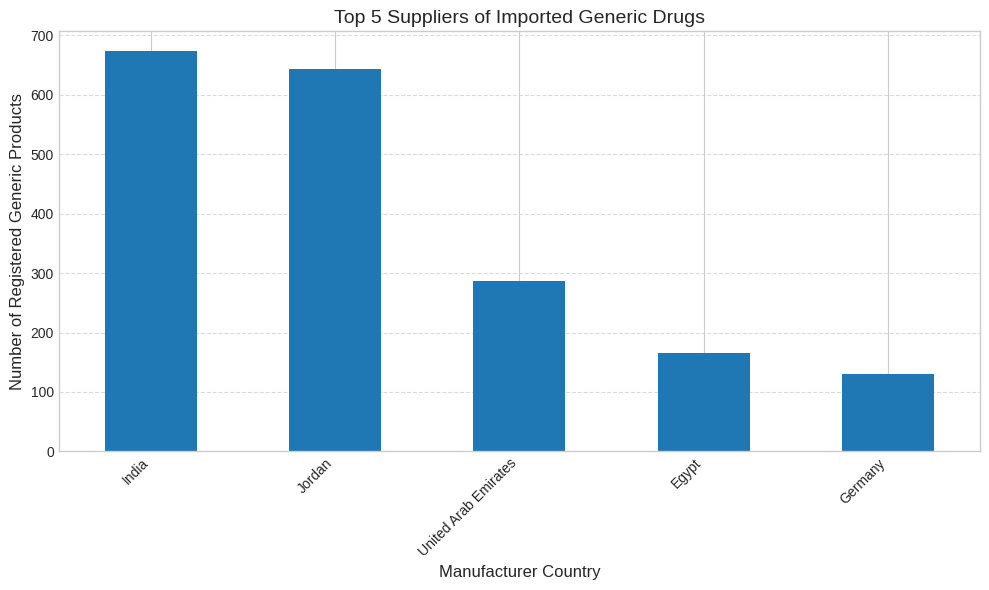

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("tab10")


print(" Data Loading and Standardization ")

try:
    df_local = pd.read_csv('Human Drugs Products Local.csv')
    df_imported = pd.read_csv('Imported human drug products.csv')
except FileNotFoundError as e:
    print(f"ERROR: Could not load the CSV files. Please check file names. {e}")
    exit()

manufacturer_col_local = [col for col in df_local.columns if 'Manufacture' in col and 'Country' not in col][0]
df_local.rename(columns={manufacturer_col_local: 'Manufacture Name'}, inplace=True)

# Data Classification
df_local['Source_Type'] = 'Local Production'
df_imported['Source_Type'] = 'Imported Drugs'

columns_to_drop = ['Unnamed: 10', 'Unnamed: 11']
df_local.drop(columns=columns_to_drop, inplace=True, errors='ignore')
df_imported.drop(columns=columns_to_drop, inplace=True, errors='ignore')

# Combine the dataframes
df_combined = pd.concat([df_local, df_imported], ignore_index=True)

# Define local and imported subsets for focused analysis
df_local_only = df_combined[df_combined['Source_Type'] == 'Local Production'].copy()
df_imported_only = df_combined[df_combined['Source_Type'] == 'Imported Drugs'].copy()

print(f"Total Registered Products (Local + Imported): {df_combined.shape[0]}")
print(df_combined['Source_Type'].value_counts())
print("-" * 50)


# Overall Market Share Analysis ---
market_share = df_combined['Source_Type'].value_counts(normalize=True) * 100
print("\nOverall Market Share (Local vs. Imported) ")
print(market_share.round(2))

# Plotting: Market Share Pie Chart
plt.figure(figsize=(8, 8))
plt.pie(
    market_share,
    labels=[f'{idx} ({val:.1f}%)' for idx, val in market_share.items()],
    autopct=lambda p: f'N={p * df_combined.shape[0] / 100:.0f}',
    startangle=90,
    colors=['#FF4500', '#008000'],
    explode=[0, 0.05],
    textprops={'fontsize': 12, 'weight': 'bold'}
)
plt.title('Registered Drug Market Share: Local vs. Imported', fontsize=16)
plt.tight_layout()
plt.show()
print("-" * 50)


# Local Production
top_local_manufacturers = df_local_only['Manufacture Name'].value_counts().head(10)
print("\nTop 10 Local Manufacturing Companies")
print(top_local_manufacturers)

#Top Local Manufacturers Bar Chart
plt.figure(figsize=(12, 6))
top_local_manufacturers.plot(kind='bar', color='#008000')
plt.title('Top 10 Local Manufacturers by Number of Registered Drugs', fontsize=14)
plt.xlabel('Manufacturer Name', fontsize=12)
plt.ylabel('Number of Local Registered Drugs', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
print("-" * 50)


# Local Company Production(What they produce)
top_local_manufacturers_names = top_local_manufacturers.index.tolist()
df_top_local = df_local_only[df_local_only['Manufacture Name'].isin(top_local_manufacturers_names)]

local_production_profile = df_top_local.groupby('Manufacture Name')['DrugType'].value_counts().unstack(fill_value=0)

# Sort by total count
local_production_profile['Total'] = local_production_profile.sum(axis=1)
local_production_profile = local_production_profile.sort_values(by='Total', ascending=False).drop(columns=['Total'])

print("\nTop 10 Local Companies: Production Profile by Drug Type ---")
print(local_production_profile)

# Stacked Bar Chart for Production
plot_data = local_production_profile[['Generic', 'NCE', 'Biological']].copy()
plot_data = plot_data.sort_values(by='Generic', ascending=True)

plt.figure(figsize=(14, 8))
plot_data.plot(kind='barh', stacked=True, figsize=(14, 8), colormap='Spectral', ax=plt.gca())

plt.title('Top 10 Local Manufacturers: Drug Production Profile by Type', fontsize=16)
plt.xlabel('Number of Registered Products', fontsize=12)
plt.ylabel('Manufacturer Name', fontsize=12)
plt.legend(title='Drug Type')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
print("-" * 50)


# Strategic Gap Analysis & Import Sources
#  Drug Type Comparison (Gap Analysis)
local_drug_type_share = df_local_only['DrugType'].value_counts(normalize=True).head(5) * 100
imported_drug_type_share = df_imported_only['DrugType'].value_counts(normalize=True).head(5) * 100

strategic_comparison = pd.DataFrame({
    'Local Production Share (%)': local_drug_type_share.round(1),
    'Imported Drugs Share (%)': imported_drug_type_share.round(1)
}).fillna(0)

strategic_comparison['Strategic Gap (Import - Local) (%)'] = (
    strategic_comparison['Imported Drugs Share (%)'] - strategic_comparison['Local Production Share (%)']
).round(1)

print("\n Strategic Gap Analysis: Local vs. Imported Drug Types ---")
print(strategic_comparison.sort_values(by='Strategic Gap (Import - Local) (%)', ascending=False))
print("-" * 50)


#Suppliers of Critical Gap Products (NCE and Biological)
df_imported_NCE = df_imported_only[df_imported_only['DrugType'] == 'NCE']
top_NCE_suppliers = df_imported_NCE['Manufacture_Country'].value_counts().head(5)

df_imported_biologics = df_imported_only[df_imported_only['DrugType'] == 'Biological']
top_biologics_suppliers = df_imported_biologics['Manufacture_Country'].value_counts().head(5)

print("\n.Top 5 Suppliers of Imported NCE Drugs (Innovative Gap)  ")
print(f"Total Imported NCE Products: {df_imported_NCE.shape[0]}")
print(top_NCE_suppliers)

print("\n.Top 5 Suppliers of Imported Biological Drugs (Critical Technology Gap)   ")
print(f"Total Imported Biological Products: {df_imported_biologics.shape[0]}")
print(top_biologics_suppliers)


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# NCE Plot
top_NCE_suppliers.plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Top 5 Suppliers of Imported NCE Drugs', fontsize=14)
axes[0].set_ylabel('Number of Registered Products', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Biological Plot
top_biologics_suppliers.plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('Top 5 Suppliers of Imported Biological Drugs', fontsize=14)
axes[1].set_ylabel('Number of Registered Products', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
print("-" * 50)
#Analysis of Imported Generic Suppliers

# Filter imported drugs that are Generic type
df_imported_generic = df_imported_only[df_imported_only['DrugType'] == 'Generic']

# Top 5 Countries supplying Imported Generic Drugs
top_generic_suppliers = df_imported_generic['Manufacture_Country'].value_counts().head(5)

print("\nTop 5 Suppliers of Imported Generic Drugs (Direct Competition) ---")
print(f"Total Imported Generic Products: {df_imported_generic.shape[0]}")
print(top_generic_suppliers)
print("-" * 50)


plt.figure(figsize=(10, 6))
top_generic_suppliers.plot(kind='bar', color='#1f77b4')
plt.title('Top 5 Suppliers of Imported Generic Drugs', fontsize=14)
plt.xlabel('Manufacturer Country', fontsize=12)
plt.ylabel('Number of Registered Generic Products', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()